# Notebook 07 (Exp 3) — Full Comparison: Exp 1 vs 2 vs 3

Aggregates all three experiments:
- Side-by-side metrics table (BLEU, ChrF, BERTScore F1)
- Bar charts: all four models across all three runs
- Loss curve comparison
- Summary discussion

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT         = Path('..').resolve()
RES_EXP1     = ROOT / 'outputs' / 'exp1' / 'results'
RES_EXP2     = ROOT / 'outputs' / 'exp2' / 'results'
RES_EXP3     = ROOT / 'outputs' / 'exp3' / 'results'
FIG_DIR      = RES_EXP3 / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

Setup complete.


## 1. Load All Scores

In [2]:
with open(RES_EXP1 / 'bleu_scores.json') as f:
    exp1 = json.load(f)
with open(RES_EXP2 / 'bleu_scores.json') as f:
    exp2 = json.load(f)
with open(RES_EXP3 / 'bleu_scores.json') as f:
    exp3 = json.load(f)

print('Exp 1 LoRA:', exp1['lora'])
print('Exp 2 LoRA:', exp2['lora'])
print('Exp 3 LoRA:', exp3['lora'])
print()
print('Exp 1 FFT: ', exp1['fft'])
print('Exp 2 FFT: ', exp2['fft'])
print('Exp 3 FFT: ', exp3['fft'])


Exp 1 LoRA: {'corpus_bleu': 0.1, 'corpus_chrf': 5.73, 'sent_bleu_mean': 2.25, 'sent_bleu_std': 3.82, 'sent_bleu_p25': 0.0, 'sent_bleu_p50': 1.03, 'sent_bleu_p75': 3.45}
Exp 2 LoRA: {'corpus_bleu': 0.12, 'corpus_chrf': 5.56, 'sent_bleu_mean': 2.13, 'sent_bleu_std': 3.61, 'sent_bleu_p25': 0.0, 'sent_bleu_p50': 0.77, 'sent_bleu_p75': 3.22, 'bert_p_mean': 0.7143, 'bert_r_mean': 0.6785, 'bert_f1_mean': 0.695}
Exp 3 LoRA: {'corpus_bleu': 0.12, 'corpus_chrf': 5.4, 'sent_bleu_mean': 2.23, 'sent_bleu_std': 4.14, 'sent_bleu_p25': 0.0, 'sent_bleu_p50': 0.72, 'sent_bleu_p75': 3.39, 'bert_p_mean': 0.8579, 'bert_r_mean': 0.825, 'bert_f1_mean': 0.8405}

Exp 1 FFT:  {'corpus_bleu': 0.09, 'corpus_chrf': 4.83, 'sent_bleu_mean': 2.21, 'sent_bleu_std': 4.06, 'sent_bleu_p25': 0.0, 'sent_bleu_p50': 0.39, 'sent_bleu_p75': 3.3}
Exp 2 FFT:  {'corpus_bleu': 0.08, 'corpus_chrf': 4.75, 'sent_bleu_mean': 2.23, 'sent_bleu_std': 3.86, 'sent_bleu_p25': 0.0, 'sent_bleu_p50': 0.63, 'sent_bleu_p75': 3.53, 'bert_p_mean':

## 2. Full Comparison Table

In [3]:
def row(scores, label):
    return {
        'Run':             label,
        'Corpus BLEU':     scores.get('corpus_bleu', '-'),
        'Corpus ChrF':     scores.get('corpus_chrf', '-'),
        'Sent BLEU Mean':  scores.get('sent_bleu_mean', '-'),
        'Sent BLEU P50':   scores.get('sent_bleu_p50', '-'),
        'BERTScore F1':    scores.get('bert_f1_mean', 'N/A'),
        'BERTScore P':     scores.get('bert_p_mean', '-'),
        'BERTScore R':     scores.get('bert_r_mean', '-'),
    }

rows = [
    row(exp1['lora'], 'Exp1 — LoRA  (3B, r=16, bidir,  3ep,  LR=2e-4)'),
    row(exp2['lora'], 'Exp2 — LoRA  (3B, r=16, bidir,  2ep+ES, LR=2e-4)'),
    row(exp3['lora'], 'Exp3 — LoRA  (3B, r=32, unidir, 2ep+ES, LR=2e-4)'),
    row(exp1['fft'],  'Exp1 — FFT   (1.5B, bidir,  3ep, LR=2e-5)'),
    row(exp2['fft'],  'Exp2 — FFT   (1.5B, bidir,  3ep, LR=5e-5)'),
    row(exp3['fft'],  'Exp3 — FFT   (1.5B, unidir, 3ep, LR=5e-5)'),
]
df = pd.DataFrame(rows).set_index('Run')

print('=== Full Three-Experiment Comparison ===')
print(df.to_string())
df.to_csv(RES_EXP3 / 'comparison_table_all_exp.csv')
print('\nSaved to outputs/exp3/results/comparison_table_all_exp.csv')


=== Full Three-Experiment Comparison ===
                                                  Corpus BLEU  Corpus ChrF  Sent BLEU Mean  Sent BLEU P50 BERTScore F1 BERTScore P BERTScore R
Run                                                                                                                                           
Exp1 — LoRA  (3B, r=16, bidir,  3ep,  LR=2e-4)           0.10         5.73            2.25           1.03          N/A           -           -
Exp2 — LoRA  (3B, r=16, bidir,  2ep+ES, LR=2e-4)         0.12         5.56            2.13           0.77        0.695      0.7143      0.6785
Exp3 — LoRA  (3B, r=32, unidir, 2ep+ES, LR=2e-4)         0.12         5.40            2.23           0.72       0.8405      0.8579       0.825
Exp1 — FFT   (1.5B, bidir,  3ep, LR=2e-5)                0.09         4.83            2.21           0.39          N/A           -           -
Exp2 — FFT   (1.5B, bidir,  3ep, LR=5e-5)                0.08         4.75            2.23           

## 3. BLEU and ChrF — All Runs

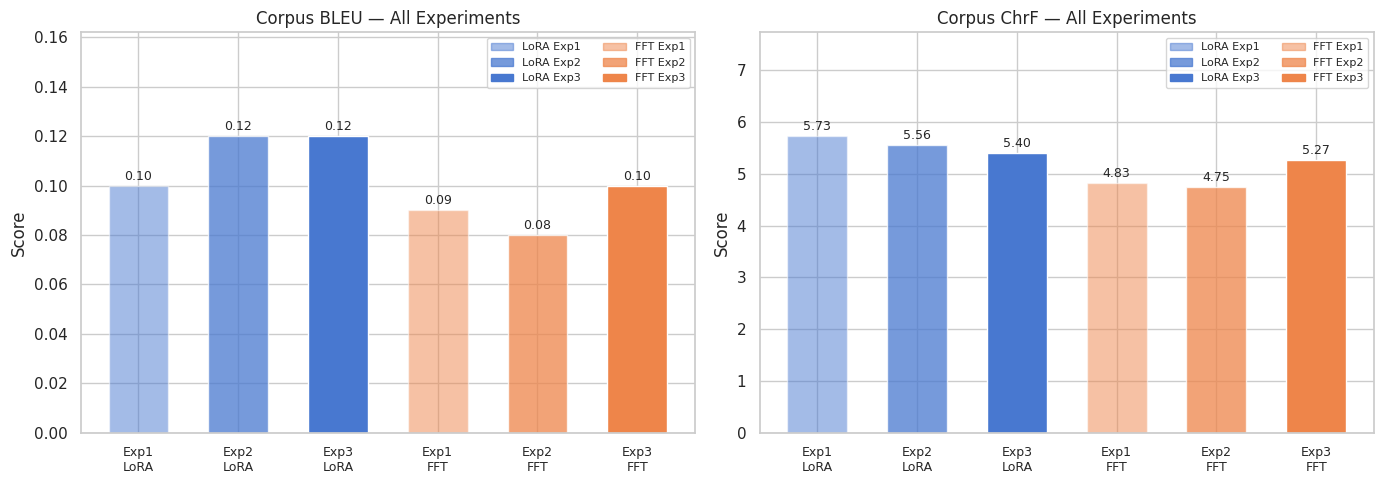

In [4]:
run_labels = [
    'Exp1\nLoRA', 'Exp2\nLoRA', 'Exp3\nLoRA',
    'Exp1\nFFT',  'Exp2\nFFT',  'Exp3\nFFT',
]
bleu_vals = [
    exp1['lora']['corpus_bleu'], exp2['lora']['corpus_bleu'], exp3['lora']['corpus_bleu'],
    exp1['fft']['corpus_bleu'],  exp2['fft']['corpus_bleu'],  exp3['fft']['corpus_bleu'],
]
chrf_vals = [
    exp1['lora']['corpus_chrf'], exp2['lora']['corpus_chrf'], exp3['lora']['corpus_chrf'],
    exp1['fft']['corpus_chrf'],  exp2['fft']['corpus_chrf'],  exp3['fft']['corpus_chrf'],
]

x      = np.arange(len(run_labels))
colors = ['#4878d0', '#4878d0', '#4878d0', '#ee854a', '#ee854a', '#ee854a']
alphas = [0.5, 0.75, 1.0, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, vals, metric in zip(axes, [bleu_vals, chrf_vals], ['Corpus BLEU', 'Corpus ChrF']):
    bars = [ax.bar(xi, v, color=c, alpha=a, edgecolor='white', width=0.6)
            for xi, v, c, a in zip(x, vals, colors, alphas)]
    for xi, v in zip(x, vals):
        ax.text(xi, v + max(vals)*0.02, f'{v:.2f}', ha='center', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(run_labels, fontsize=9)
    ax.set_ylabel('Score'); ax.set_title(f'{metric} — All Experiments')
    ax.set_ylim(0, max(vals) * 1.35 if max(vals) > 0 else 1)
    # legend
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#4878d0', alpha=0.5, label='LoRA Exp1'),
        Patch(color='#4878d0', alpha=0.75, label='LoRA Exp2'),
        Patch(color='#4878d0', alpha=1.0, label='LoRA Exp3'),
        Patch(color='#ee854a', alpha=0.5, label='FFT Exp1'),
        Patch(color='#ee854a', alpha=0.75, label='FFT Exp2'),
        Patch(color='#ee854a', alpha=1.0, label='FFT Exp3'),
    ], fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'all_exp_bleu_chrf.png', dpi=150)
plt.show()


## 4. BERTScore F1 — Exp 2 vs Exp 3

(Exp 1 was not scored with BERTScore)

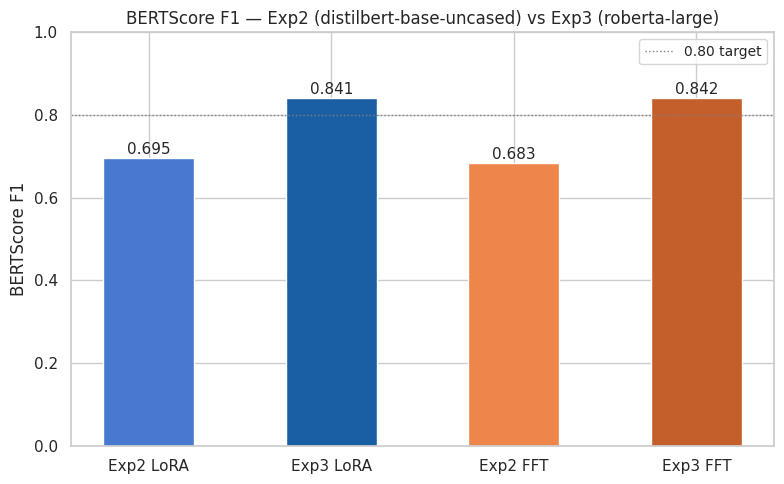

In [5]:
labels_bert = ['Exp2 LoRA', 'Exp3 LoRA', 'Exp2 FFT', 'Exp3 FFT']
f1_vals     = [
    exp2['lora'].get('bert_f1_mean', 0),
    exp3['lora'].get('bert_f1_mean', 0),
    exp2['fft'].get('bert_f1_mean', 0),
    exp3['fft'].get('bert_f1_mean', 0),
]
colors_b = ['#4878d0', '#1a5fa3', '#ee854a', '#c45e2a']

x = np.arange(len(labels_bert))
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x, f1_vals, color=colors_b, edgecolor='white', width=0.5)
for bar in bars:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(labels_bert, fontsize=11)
ax.set_ylabel('BERTScore F1')
ax.set_ylim(0, 1)

# note the different bert models
bert2_model = exp2.get('bert_model', 'distilbert-base-uncased')
bert3_model = exp3.get('bert_model', 'roberta-large')
ax.set_title(f'BERTScore F1 — Exp2 ({bert2_model}) vs Exp3 ({bert3_model})')
ax.axhline(0.8, color='gray', linestyle=':', linewidth=1, label='0.80 target')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'exp2_vs_exp3_bertscore.png', dpi=150)
plt.show()


## 5. Loss Curve Gallery

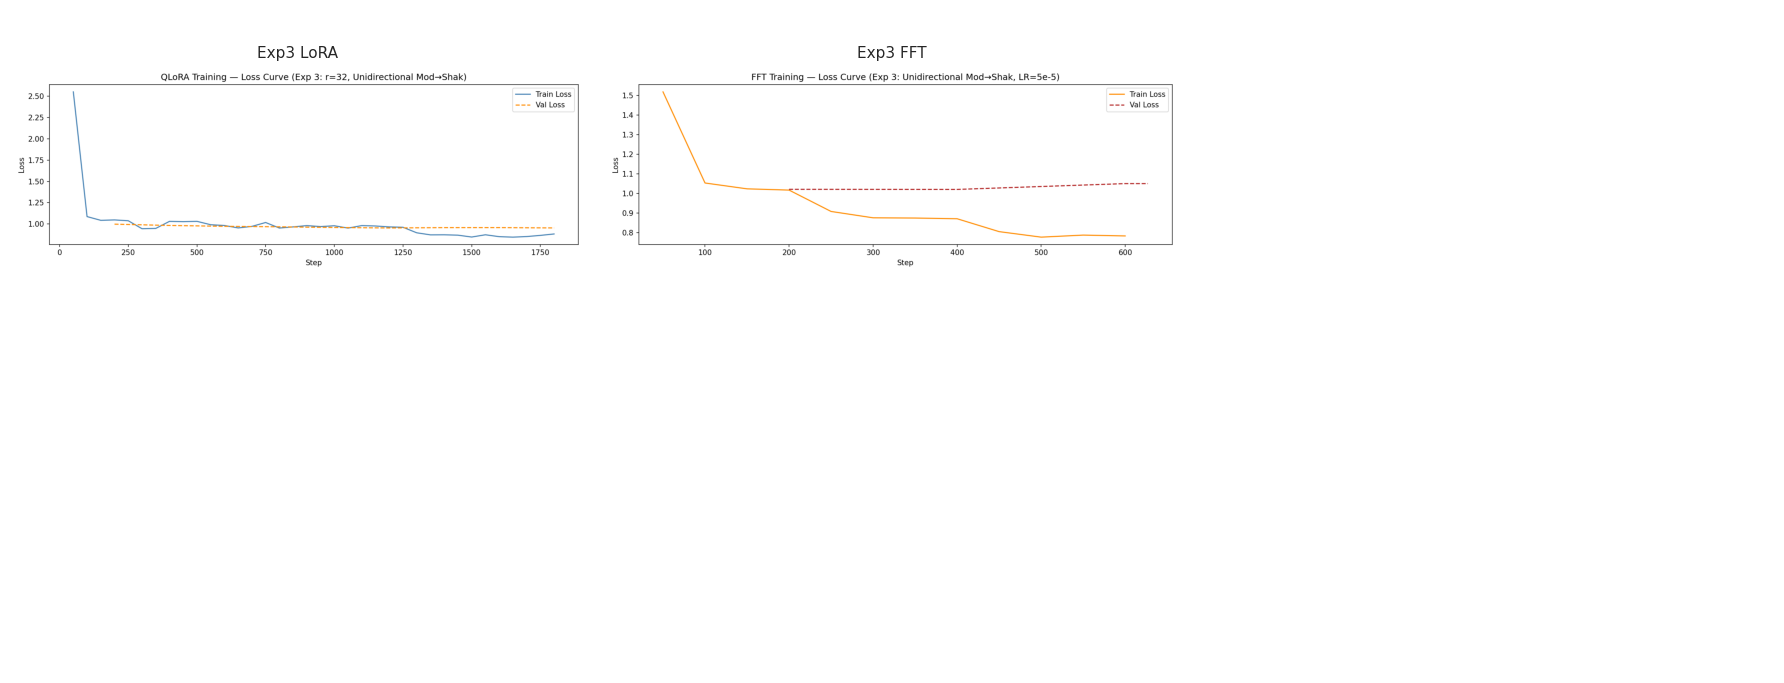

In [6]:
from PIL import Image
import os

curve_map = {
    'Exp1 LoRA': FIG_DIR / 'lora_loss_curve.png',
    'Exp2 LoRA': FIG_DIR / 'exp2_lora_loss_curve.png',
    'Exp3 LoRA': FIG_DIR / 'exp3_lora_loss_curve.png',
    'Exp1 FFT':  FIG_DIR / 'fft_loss_curve.png',
    'Exp2 FFT':  FIG_DIR / 'exp2_fft_loss_curve.png',
    'Exp3 FFT':  FIG_DIR / 'exp3_fft_loss_curve.png',
}
existing = {k: v for k, v in curve_map.items() if v.exists()}

if existing:
    n = len(existing)
    fig, axes = plt.subplots(2, 3, figsize=(18, 7))
    axes = axes.flatten()
    for ax, (title, path) in zip(axes, existing.items()):
        ax.imshow(Image.open(path))
        ax.axis('off')
        ax.set_title(title, fontsize=11)
    for ax in axes[len(existing):]:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'all_exp_loss_curves.png', dpi=150)
    plt.show()
else:
    print('No loss curve images found — run training notebooks first.')


## 6. Discussion

| Change | Exp 1→2 | Exp 2→3 |
|--------|---------|---------|
| **LoRA overfitting** | Fixed: 2 epochs + EarlyStopping | Carried forward |
| **FFT underfitting** | Fixed: LR 2e-5→5e-5 | Carried forward |
| **Training direction** | Bidirectional | **Unidirectional (Mod→Shak only)** |
| **LoRA rank** | r=16 (~13M params) | **r=32 (~26M params)** |
| **Metric** | Added BERTScore (distilbert) | **BERTScore with roberta-large** |

**Expected outcome of Exp 3:**
- LoRA BLEU/BERTScore should improve vs Exp 2 — both r=32 (more expressive adapter) and unidirectional training (focused learning) point in the same direction
- FFT should also improve slightly from unidirectional data (cleaner signal per step)
- roberta-large BERTScore numbers are not directly comparable to exp2's distilbert scores — use them as the new primary quality metric

**Further work (Exp 4+):** Multi-reference BLEU, BF16 LoRA (no 4-bit quantization), larger LoRA base (r=64).
